# Hierarchical Clustering — A Beginner-Friendly Project

**Goal:** Learn *hierarchical clustering* end-to-end on a small, intuitive dataset of mall customers, and understand **how it works**, not just how to call a function.

---

## 1. What is Hierarchical Clustering?

Clustering means grouping data points so that points **inside a group are similar** and points **in different groups are different** — without anyone telling us the "correct" labels (this is *unsupervised* learning).

**Hierarchical clustering** builds a *tree* of clusters. There are two flavours:

| Type | Direction | Idea |
|------|-----------|------|
| **Agglomerative** (bottom-up) | merge | Start with every point as its own cluster, then repeatedly merge the two closest clusters until only one remains. |
| **Divisive** (top-down) | split | Start with one big cluster containing everything, then repeatedly split it. |

Agglomerative is by far the most common, and it's what we'll use.

**The key output is a *dendrogram*** — a tree diagram that records *which* clusters were merged and *how far apart* they were. By "cutting" this tree at a chosen height, we decide how many clusters we want. We never have to fix the number of clusters in advance.

Two ingredients control the merging:
1. **Distance metric** — how we measure the distance between two *points* (we'll use Euclidean / straight-line distance).
2. **Linkage** — how we measure the distance between two *clusters* (single, complete, average, ward — explained later).


## 2. Setup

Import the libraries we need.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
sns.set_theme(style="whitegrid")


## 3. Load and Explore the Data

Our dataset `customers.csv` describes **60 mall customers** with three features:

- **Age** — customer's age in years
- **Annual_Income_k** — annual income in thousands of dollars
- **Spending_Score** — a 1–100 score the mall assigns based on spending behaviour (high = spends a lot)



In [2]:
df = pd.read_csv("customers.csv")
print("Shape:", df.shape)
df.head()

Shape: (60, 4)


,CustomerID,Age,Annual_Income_k,Spending_Score
0,1,47,84,26
1,2,42,80,87
2,3,44,57,52
3,4,44,80,87
4,5,28,35,82


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       60 non-null     int64
 1   Age              60 non-null     int64
 2   Annual_Income_k  60 non-null     int64
 3   Spending_Score   60 non-null     int64
dtypes: int64(4)
memory usage: 2.0 KB


In [4]:
df.describe().round(1)

,CustomerID,Age,Annual_Income_k,Spending_Score
count,60.0,60.0,60.0,60.0
mean,30.5,41.0,55.7,50.1
std,17.5,11.1,24.8,27.6
min,1.0,18.0,22.0,7.0
25%,15.8,34.8,31.0,22.0
50%,30.5,43.0,54.0,49.5
75%,45.2,49.0,80.5,79.2
max,60.0,61.0,91.0,91.0


## 4. Visualise the Raw Data

Before clustering, always *look* at the data. The two most behaviour-revealing features are **Annual Income** and **Spending Score**, so let's plot them against each other.

Even with the naked eye you can already start to spot natural groupings.

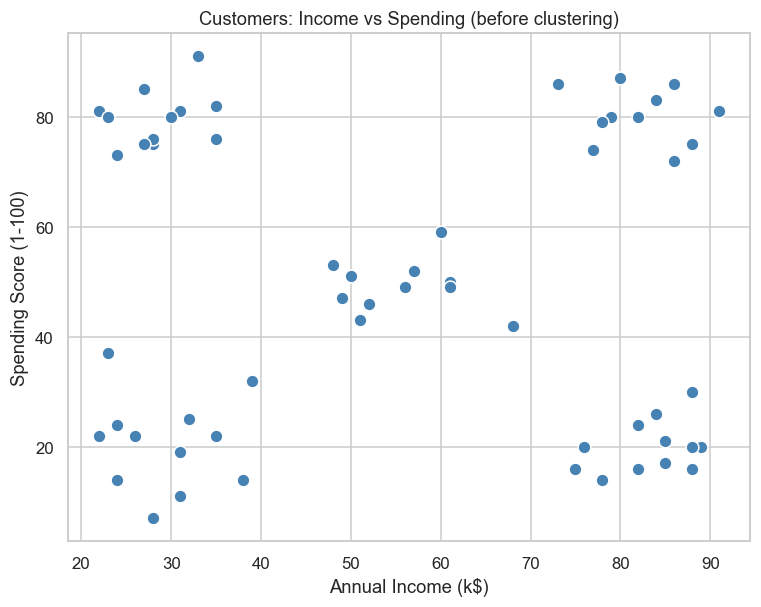

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Annual_Income_k"], df["Spending_Score"],
            s=70, c="steelblue", edgecolor="white")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customers: Income vs Spending (before clustering)")
plt.show()

A `pairplot` lets us see every pair of features at once, which helps us understand the overall structure.

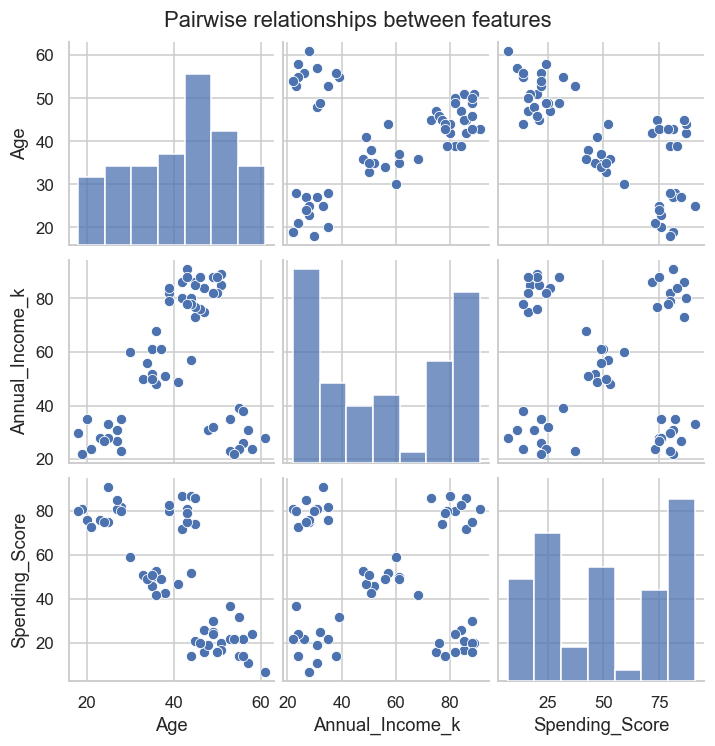

In [20]:
sns.pairplot(df[["Age", "Annual_Income_k", "Spending_Score"]],
             diag_kind="hist", height=2.2,
             plot_kws=dict(s=45, edgecolor="white"))
plt.suptitle("Pairwise relationships between features", y=1.02)
plt.show()

## 5. Why We Scale the Features First

Hierarchical clustering is **distance-based**. If one feature has a much larger numeric range than another, it will dominate the distance calculation and effectively drown out the others.

In our data, *Annual Income* spans a wider range than *Spending Score*, so without scaling, income would unfairly dominate. The fix is **standardisation**: rescale every feature to have mean 0 and standard deviation 1, so each feature contributes fairly.

We'll cluster on **Income** and **Spending Score** (the two behavioural features) so the results are easy to visualise on a 2-D plot. *(In a real project you could include `Age` and more features too — the method is identical.)*

In [ ]:
features = ["Annual_Income_k", "Spending_Score"]
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Quick check: each scaled feature now has mean ~0 and std ~1
print("Mean after scaling:", X_scaled.mean(axis=0).round(2))
print("Std  after scaling:", X_scaled.std(axis=0).round(2))

Mean after scaling: [-0. -0.]
Std  after scaling: [1. 1.]


## 6. Distance and Linkage — The Two Core Ideas

**Distance between two points.** We use **Euclidean distance** — the ordinary straight-line distance. For two points $p=(p_1,p_2)$ and $q=(q_1,q_2)$:

$$ d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2} $$

**Distance between two *clusters* (linkage).** Once points are grouped, we need a rule for how far apart two groups are. The common choices:

| Linkage | Distance between clusters A and B = ... |
|---------|------------------------------------------|
| **Single** | distance between the *closest* pair of points (one from each). Can produce long, straggly chains. |
| **Complete** | distance between the *farthest* pair of points. Produces compact, roughly equal-diameter clusters. |
| **Average** | the *average* distance over all cross pairs. A balanced compromise. |
| **Ward** | merge the pair that increases total *within-cluster variance* the least. Tends to give tidy, similar-sized clusters and is a great default. |

We'll use **Ward** linkage as our main choice and compare the others later.

## 7. The Dendrogram — The Heart of Hierarchical Clustering

`scipy`'s `linkage` function performs the whole agglomerative merging process and returns a **linkage matrix** `Z` that records, at each step, *which two clusters were merged* and *the distance between them*. We then draw it as a **dendrogram**.

**How to read a dendrogram:**
- Each **leaf** at the bottom is a single customer.
- Each **horizontal bar (a "join")** is a merge of two clusters.
- The **height** of a join = how far apart those two clusters were when merged. **Low joins = very similar; tall joins = quite different.**
- To get *k* clusters, imagine slicing the tree with a horizontal line: the number of vertical lines your cut crosses is the number of clusters.

In [ ]:
# Build the linkage matrix using Ward linkage on the scaled data
Z = linkage(X_scaled, method="ward")
# print("Linkage matrix shape:", Z.shape, " (= n_points - 1 merges)")
# print("First 5 merges:\n", np.round(Z[:5], 3))

Linkage matrix shape: (59, 4)  (= n_points - 1 merges)
First 5 merges:
 [[1.0e+00 3.0e+00 0.0e+00 2.0e+00]
 [2.2e+01 4.7e+01 0.0e+00 2.0e+00]
 [2.3e+01 4.0e+01 3.7e-02 2.0e+00]
 [3.8e+01 3.9e+01 3.7e-02 2.0e+00]
 [9.0e+00 5.1e+01 4.1e-02 2.0e+00]]


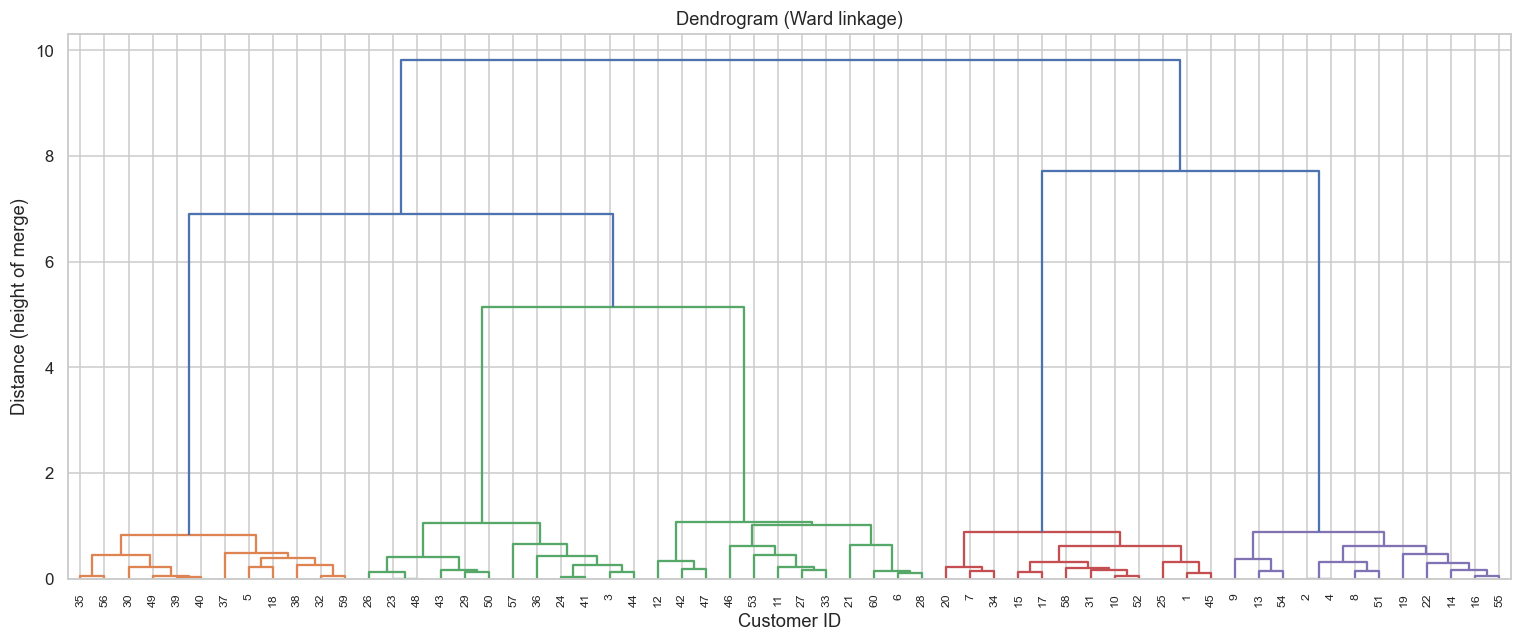

In [ ]:
plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    labels=df["CustomerID"].values,
    leaf_rotation=90,
    leaf_font_size=8,
)

plt.title("Dendrogram (Ward linkage)")
plt.xlabel("Customer ID")
plt.ylabel("Distance (height of merge)")
plt.tight_layout()
plt.show()


## 8. Choosing the Number of Clusters

A common rule of thumb: **find the tallest vertical gap that is *not* crossed by any horizontal join, and cut there.** A tall gap means clusters stayed separate for a long "distance range" before being forced to merge — a sign of a natural, stable grouping.

Below we redraw the dendrogram and add a dashed horizontal **cut line**. `color_threshold` colours the branches below the cut so each resulting cluster gets its own colour.

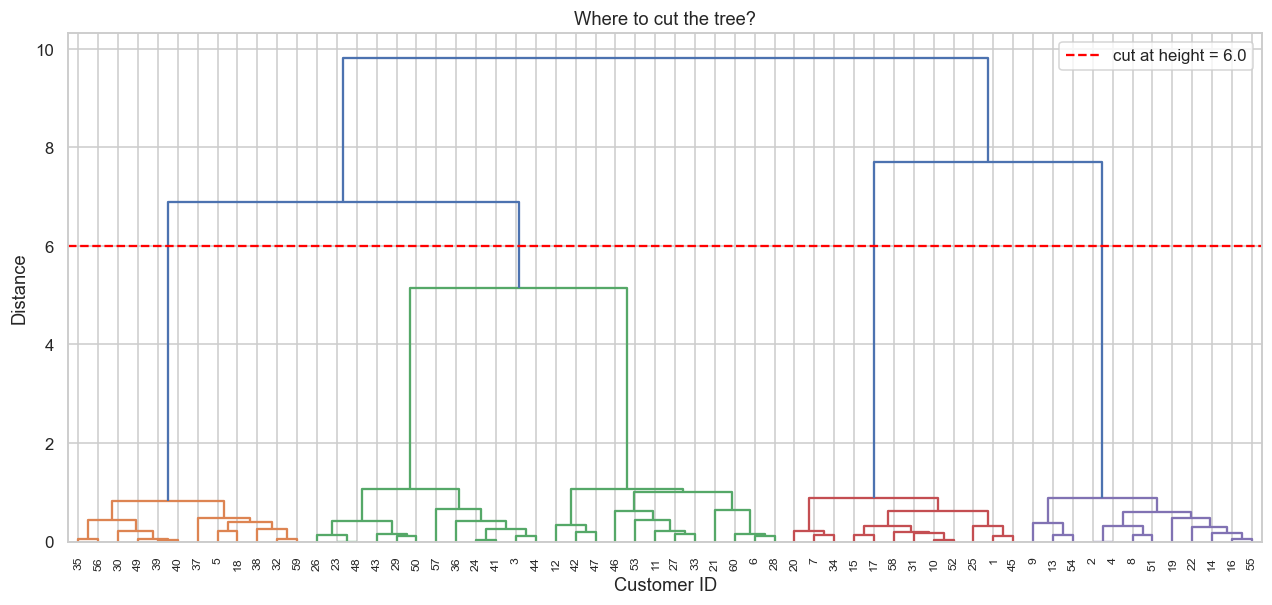

In [ ]:
cut_height = 6.0   # try changing this and watch the number of colours change

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    labels=df["CustomerID"].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=cut_height,
)
plt.axhline(y=cut_height, color="red", linestyle="--", linewidth=1.5,
            label=f"cut at height = {cut_height}")
plt.title("Where to cut the tree?")
plt.xlabel("Customer ID")
plt.ylabel("Distance")
plt.legend()
plt.show()

We can also let the data suggest *k* using the **silhouette score** (ranges -1 to 1; higher = better separated, more cohesive clusters). We try a few values of *k* and pick the best.

In [11]:
for k in range(2, 8):
    labels_k = fcluster(Z, t=k, criterion="maxclust")
    score = silhouette_score(X_scaled, labels_k)
    print(f"k = {k}:  silhouette = {score:.3f}")

k = 2:  silhouette = 0.405
k = 3:  silhouette = 0.518
k = 4:  silhouette = 0.648
k = 5:  silhouette = 0.740
k = 6:  silhouette = 0.659
k = 7:  silhouette = 0.595


Both the dendrogram (a clear tall gap separating ~5 branches) and the silhouette scores point to the same answer. We'll go with **k = 5**.

## 9. Apply Agglomerative Clustering

Now we run the clustering for real using scikit-learn's `AgglomerativeClustering` with **5 clusters** and **Ward** linkage, then attach the cluster label to every customer.

In [ ]:
model = AgglomerativeClustering(n_clusters=5, linkage="ward")
df["Cluster"] = model.fit_predict(X_scaled)
print("Customers per cluster:")
print(df["Cluster"].value_counts().sort_index())
df.head()

Customers per cluster:
Cluster
0    12
1    12
2    12
3    12
4    12
Name: count, dtype: int64


,CustomerID,Age,Annual_Income_k,Spending_Score,Cluster
0,1,47,84,26,2
1,2,42,80,87,4
2,3,44,57,52,1
3,4,44,80,87,4
4,5,28,35,82,3


## 10. Visualise the Clusters

Let's colour each customer by its assigned cluster. Because we clustered on Income and Spending, the colours should line up neatly with the visual groups we saw earlier. We also mark each cluster's **centre** (its average position) with a black star.

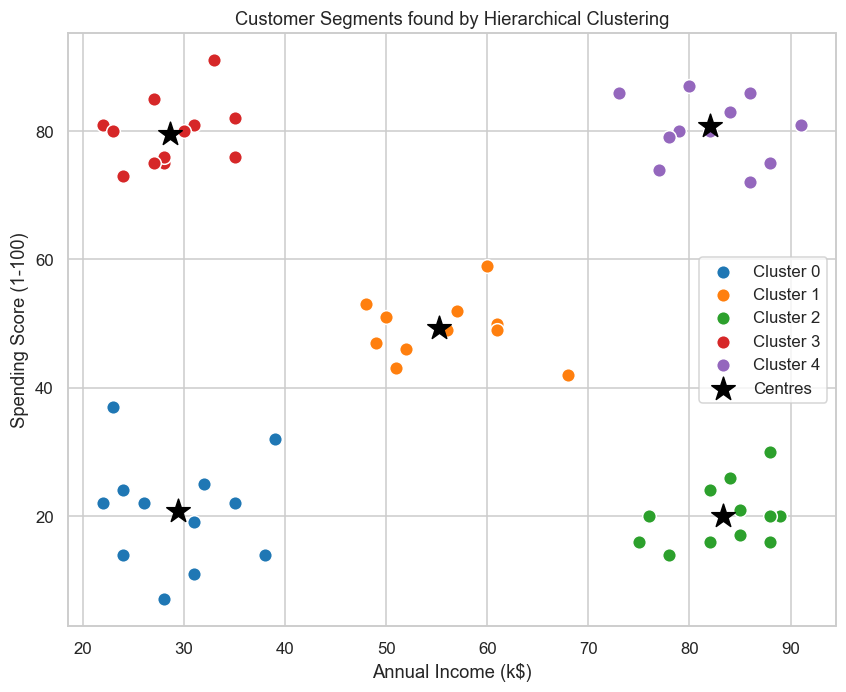

In [13]:
plt.figure(figsize=(9, 7))
palette = sns.color_palette("tab10", df["Cluster"].nunique())

for c in sorted(df["Cluster"].unique()):
    sub = df[df["Cluster"] == c]
    plt.scatter(sub["Annual_Income_k"], sub["Spending_Score"],
                s=80, color=palette[c], edgecolor="white",
                label=f"Cluster {c}")

# Plot cluster centres (in original units)
centres = df.groupby("Cluster")[features].mean()
plt.scatter(centres["Annual_Income_k"], centres["Spending_Score"],
            s=260, c="black", marker="*", label="Centres")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments found by Hierarchical Clustering")
plt.legend()
plt.show()

## 11. How Linkage Choice Changes the Result

The linkage rule genuinely changes the tree. Here are the four main linkages side by side on the same data. Notice how **single** linkage tends to "chain" points together, while **ward** and **complete** give more balanced, compact clusters.

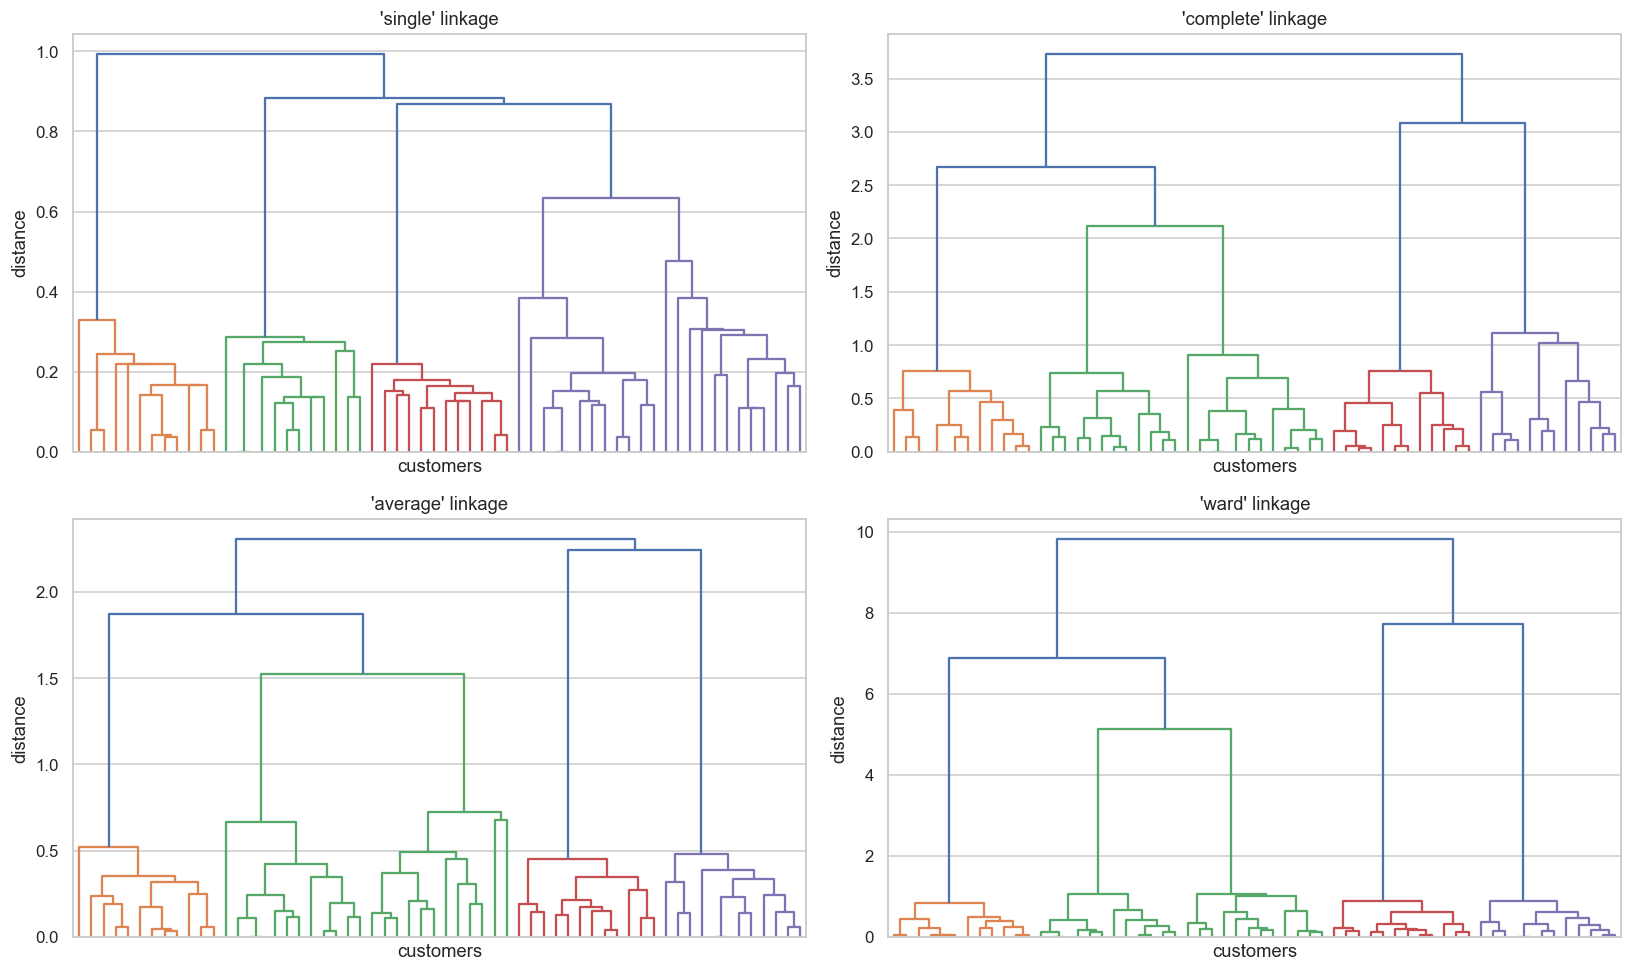

In [14]:
methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, method in zip(axes.ravel(), methods):
    Z_m = linkage(X_scaled, method=method)
    dendrogram(Z_m, ax=ax, no_labels=True, color_threshold=0.7 * Z_m[:, 2].max())
    ax.set_title(f"'{method}' linkage")
    ax.set_xlabel("customers")
    ax.set_ylabel("distance")
plt.tight_layout()
plt.show()

## 12. Interpret the Clusters (the part that creates business value)

Numbers are only useful once we translate them into plain language. Let's summarise the average customer in each cluster and give each segment a human name.

In [15]:
summary = (df.groupby("Cluster")[["Age", "Annual_Income_k", "Spending_Score"]]
             .mean().round(1))
summary["Num_Customers"] = df["Cluster"].value_counts().sort_index()
summary

,Age,Annual_Income_k,Spending_Score,Num_Customers
Cluster,,,,
0,54.6,29.4,20.8,12
1,36.2,55.2,49.3,12
2,47.9,83.3,20.0,12
3,23.8,28.6,79.6,12
4,42.4,82.0,80.8,12


In [16]:
# Auto-generate a simple label for each cluster from its income & spending level
def describe(row):
    inc = "high-income" if row["Annual_Income_k"] >= 65 else \
          ("low-income" if row["Annual_Income_k"] <= 40 else "mid-income")
    spend = "big spender" if row["Spending_Score"] >= 65 else \
            ("low spender" if row["Spending_Score"] <= 35 else "moderate spender")
    return f"{inc}, {spend}"

summary["Persona"] = summary.apply(describe, axis=1)
summary[["Age", "Annual_Income_k", "Spending_Score", "Num_Customers", "Persona"]]

,Age,Annual_Income_k,Spending_Score,Num_Customers,Persona
Cluster,,,,,
0,54.6,29.4,20.8,12,"low-income, low spender"
1,36.2,55.2,49.3,12,"mid-income, moderate spender"
2,47.9,83.3,20.0,12,"high-income, low spender"
3,23.8,28.6,79.6,12,"low-income, big spender"
4,42.4,82.0,80.8,12,"high-income, big spender"


**Reading the segments (your exact cluster numbers may differ between runs):**

- **High income + high spending** → premium, high-value customers. *Target them with loyalty perks and new premium products.*
- **High income + low spending** → wealthy but cautious. *Lots of untapped potential; try personalised offers to convert them.*
- **Low income + high spending** → enthusiastic younger shoppers. *Engage with deals, trends, and instalment options.*
- **Low income + low spending** → budget-conscious. *Reach with value bundles and discounts.*
- **Mid income + moderate spending** → the mainstream majority. *Steady revenue; keep them satisfied.*

This is exactly the kind of insight a marketing team can act on — and we produced it with no pre-existing labels at all.

## 13. Summary — Key Takeaways

1. **Hierarchical (agglomerative) clustering** starts with every point alone and repeatedly merges the closest clusters, building a tree.
2. The **dendrogram** is the central tool: its **heights show how different** merged clusters are, and **cutting it** decides the number of clusters — no need to fix *k* up front.
3. **Scale your features** first, because the method relies on distances.
4. **Linkage matters** — *ward* is a strong, balanced default; *single* can produce stringy chains.
5. Choose *k* using the **dendrogram's tallest uncrossed gap** and confirm with a metric like the **silhouette score**.
6. The real payoff is **interpretation**: turning cluster statistics into named, actionable customer personas.

### Things to try next
- Add `Age` (and more features) to the clustering and see how segments change.
- Change `cut_height` in Section 8 and watch the cluster count change.
- Swap `linkage="ward"` for `"complete"` or `"average"` and compare.
- Try the same workflow on the classic *Iris* or *Mall Customers* datasets.

*Happy clustering!*